In [1]:
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
from sklearn.model_selection import train_test_split

df = pd.read_json(
    "../data/raw/Sarcasm_Headlines_Dataset.json",
    lines=True
)

df = df[["headline", "is_sarcastic"]].dropna()
df = df.drop_duplicates(subset="headline").reset_index(drop=True)

X = df["headline"]
y = df["is_sarcastic"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

## 1. Build TF-IDF features

In [3]:
tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    max_features=20000,
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

lowercase=True converts all text to lowercase, so "Lump" and "lump" are treated as the same word.

ngram_range=(1, 2) uses both single words and two-word phrases.

Unigrams: "breaking", "news"

Bigrams: "breaking news"

max_features=20000 keeps at most the 20,000 most useful vocabulary features.

min_df=2 ignores words/phrases that appear in fewer than 2 headlines. This helps remove extremely rare terms and typos.

In [4]:
print("Training matrix:", X_train_tfidf.shape)
print("Validation matrix:", X_val_tfidf.shape)
print("Test matrix:", X_test_tfidf.shape)

Training matrix: (19952, 20000)
Validation matrix: (4275, 20000)
Test matrix: (4276, 20000)


## 2. Train Logistic Regression

In [5]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

Make the prediction on Validation set

In [6]:
y_val_pred = log_reg.predict(X_val_tfidf)

## 3. Evaluate the model

In [7]:
accuracy = accuracy_score(y_val, y_val_pred)

print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.8465


In [8]:
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Precision: 0.8305
Recall:    0.8510
F1 Score:  0.8406


In [9]:
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=["Not Sarcastic", "Sarcastic"]
    )
)

               precision    recall  f1-score   support

Not Sarcastic       0.86      0.84      0.85      2242
    Sarcastic       0.83      0.85      0.84      2033

     accuracy                           0.85      4275
    macro avg       0.85      0.85      0.85      4275
 weighted avg       0.85      0.85      0.85      4275



## Confusion matrix

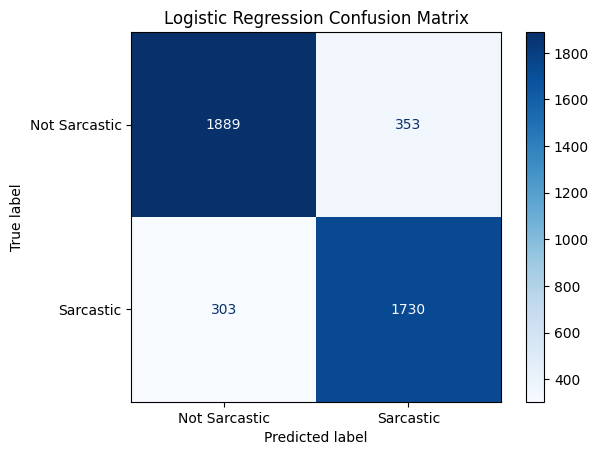

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred,
    display_labels=["Not Sarcastic", "Sarcastic"],
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

that means:

1889 = True Negatives: correctly predicted Not Sarcastic

353 = False Positives: actually Not Sarcastic, but predicted Sarcastic

303 = False Negatives: actually Sarcastic, but predicted Not Sarcastic

1730 = True Positives: correctly predicted Sarcastic

## 5. Looking at actual mistakes

In [11]:
results = pd.DataFrame({
    "headline": X_val,
    "actual": y_val,
    "predicted": y_val_pred
})

errors = results[
    results["actual"] != results["predicted"]
]

errors.head(15)

,headline,actual,predicted
12723,delta air lines resumes flights after computer...,0,1
22108,ohio moves to ban abortion after 6 weeks of pr...,0,1
8039,'black panther' sequel officially confirmed by...,0,1
11712,kinda creepy peter pan pranks disney world,0,1
12239,risk champ flunks geography test,1,0
4812,blagojevich claims behavior was just elaborate...,1,0
10075,gated-community members wish there was somethi...,1,0
11349,cops attempt to unlock phone of man they kille...,0,1
26749,it only took 7 seconds for this kylie jenner a...,0,1
21515,too big to eat,0,1


Looking specifically at sarcastic headlines the model missed:

In [12]:
false_negatives = results[
    (results["actual"] == 1) &
    (results["predicted"] == 0)
]

false_negatives.head(10)

,headline,actual,predicted
12239,risk champ flunks geography test,1,0
4812,blagojevich claims behavior was just elaborate...,1,0
10075,gated-community members wish there was somethi...,1,0
8189,ugly custody battle over ian mckellen narrowly...,1,0
19785,fbi seizes massive anthrax stockpile,1,0
2367,"michelle obama: 'well, there are 8 years of my...",1,0
14073,heston: 'we must arm ourselves if we are to de...,1,0
12338,"amazon warehouses stocked with 20,000 doctors ...",1,0
19474,peripheral acquaintance casually mentions she ...,1,0
5026,security guard makes passing women feel unsafe,1,0


And non-sarcastic headlines incorrectly classified as sarcasm:

In [13]:
false_positives = results[
    (results["actual"] == 0) &
    (results["predicted"] == 1)
]

false_positives.head(10)

,headline,actual,predicted
12723,delta air lines resumes flights after computer...,0,1
22108,ohio moves to ban abortion after 6 weeks of pr...,0,1
8039,'black panther' sequel officially confirmed by...,0,1
11712,kinda creepy peter pan pranks disney world,0,1
11349,cops attempt to unlock phone of man they kille...,0,1
26749,it only took 7 seconds for this kylie jenner a...,0,1
21515,too big to eat,0,1
219,down with cutesy cleaning supplies!,0,1
4233,federal reserve accidentally leaks secret docu...,0,1
20750,ted cruz will name carly fiorina as his runnin...,0,1


## 6. Inspect what the model learned

Logistic Regression assigns coefficients to the TF-IDF features, so we can inspect which terms most strongly push the model toward sarcasm.

In [14]:
feature_names = tfidf.get_feature_names_out()
coefficients = log_reg.coef_[0]

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

Most Sarcasm associated feature:

In [15]:
feature_importance.sort_values(
    "coefficient",
    ascending=False
).head(20)

,feature,coefficient
9359,nation,6.231111
8590,man,5.709857
1020,area,5.471801
12022,report,4.737125
9791,of,4.382613
8363,local,3.535749
10363,only,3.487092
866,announces,3.296775
6207,he,3.264069
2167,by,3.247246


Most non sarcasm associated feature:

In [16]:
feature_importance.sort_values(
    "coefficient"
).head(20)

,feature,coefficient
15420,the,-11.077262
7356,is,-7.527956
764,and,-6.673031
17527,trump,-5.472314
19035,why,-4.778835
19904,your,-4.703249
992,are,-4.121289
747,an,-4.009294
9298,my,-3.743289
4003,donald,-3.454410


## Feature Importance Analysis

The most influential features for predicting the sarcastic class include terms such as **"nation," "man," "area," "report," "local," "study," "announces,"** and **"unveils."**

Several of these words resemble recurring stylistic patterns used in satirical news headlines. This suggests that the model may be learning publication-specific or genre-specific cues in addition to genuine linguistic indicators of sarcasm.

This is an important limitation of the dataset because sarcastic examples primarily come from a satirical news source, while non-sarcastic examples come from a conventional news source. As a result, strong validation performance may partly reflect differences in writing style and topic distribution rather than a general ability to understand sarcasm.

## Baseline Model Conclusions

The TF-IDF + Logistic Regression model achieved approximately **85% validation accuracy**, with a macro F1-score of **0.85**.

Performance was relatively balanced across both classes:

- Non-sarcastic headlines achieved an F1-score of **0.85**.
- Sarcastic headlines achieved an F1-score of **0.84**.
- The model correctly classified 1,889 non-sarcastic headlines and 1,730 sarcastic headlines.
- It produced 353 false positives and 303 false negatives.

The results indicate that lexical and n-gram features captured by TF-IDF provide a strong baseline for sarcasm detection. However, the remaining errors suggest that sarcasm cannot always be identified from surface-level word patterns alone and may require deeper semantic or contextual understanding.